# World Cup 2026 Prediction Model

In [1]:
import json, math, random, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_BASE = "https://raw.githubusercontent.com/Hicruben/world-cup-2026-prediction-model/main/data/"

def fetch_json(name):
    with urllib.request.urlopen(RAW_BASE + name) as resp:
        return json.loads(resp.read().decode())

results_data = fetch_json("results.json")
elo_calibrated = fetch_json("elo-calibrated.json")
wc2026_data = fetch_json("wc2026-results.json")
matches = results_data["matches"]

In [2]:
DC_RHO = -0.13
HOME_ADV = 75

def dc_tau(a, b, lam, mu, rho):
    if a == 0 and b == 0:
        return 1 - lam * mu * rho
    if a == 0 and b == 1:
        return 1 + lam * rho
    if a == 1 and b == 0:
        return 1 + mu * rho
    if a == 1 and b == 1:
        return 1 - rho
    return 1.0

def expected_score(ra, rb, hb=0):
    return 1 / (1 + 10 ** ((rb - (ra + hb)) / 400))

def expected_goals(rating, opp, hb=0):
    diff = (rating + hb) - opp
    return max(0.3, min(3.5, 1.35 + diff / 400))

def poisson_pmf(k, lam):
    if lam <= 0:
        return 1.0 if k == 0 else 0.0
    p = math.exp(-lam)
    for i in range(1, k + 1):
        p *= lam / i
    return p

def match_prob(ra, rb, hb=0, max_goals=8):
    lam = expected_goals(ra, rb, hb)
    mu = expected_goals(rb, ra, -hb / 2)
    win_a = draw = win_b = 0.0
    for a in range(max_goals + 1):
        pa = poisson_pmf(a, lam)
        for b in range(max_goals + 1):
            tau = dc_tau(a, b, lam, mu, DC_RHO)
            p = pa * poisson_pmf(b, mu) * tau
            if a > b:
                win_a += p
            elif a < b:
                win_b += p
            else:
                draw += p
    total = win_a + draw + win_b
    return {"winA": win_a / total, "draw": draw / total, "winB": win_b / total, "xgA": lam, "xgB": mu}

def sample_scoreline(ra, rb, hb=0, allow_draw=True, rng=random.random):
    def poisson_sample(lam):
        L, k, p = math.exp(-lam), 0, 1.0
        while True:
            p *= rng()
            if p <= L:
                return k
            k += 1
    ea = expected_goals(ra, rb, hb)
    eb = expected_goals(rb, ra, -hb / 2)
    ga, gb = poisson_sample(ea), poisson_sample(eb)
    if not allow_draw and ga == gb:
        if rng() < expected_score(ra, rb, hb):
            ga += 1
        else:
            gb += 1
    return ga, gb

In [3]:
p = match_prob(2074, 1927)
print(p)

{'winA': 0.5316238800557611, 'draw': 0.2679417548347348, 'winB': 0.20043436510950408, 'xgA': 1.7175, 'xgB': 0.9825000000000002}


In [4]:
SEED = {
    "argentina": 2085, "france": 2065, "spain": 2055, "brazil": 2045, "england": 2000,
    "portugal": 1980, "netherlands": 1965, "germany": 1945, "belgium": 1925, "italy": 1915,
    "colombia": 1890, "uruguay": 1875, "croatia": 1870, "morocco": 1840, "switzerland": 1825,
    "usa": 1830, "mexico": 1825, "japan": 1810, "senegal": 1795, "denmark": 1790,
    "ecuador": 1760, "australia": 1735, "south-korea": 1730, "iran": 1720, "poland": 1715,
    "canada": 1700, "serbia": 1695, "wales": 1665, "ghana": 1665, "tunisia": 1655,
    "ivory-coast": 1655, "nigeria": 1645, "saudi-arabia": 1640, "qatar": 1630, "egypt": 1620,
    "algeria": 1615, "scotland": 1610, "cameroon": 1600, "paraguay": 1595, "venezuela": 1590,
    "chile": 1580, "peru": 1575, "czech-republic": 1570, "bosnia-and-herzegovina": 1545,
    "south-africa": 1520, "new-zealand": 1495, "panama": 1480, "jamaica": 1460,
    "honduras": 1440, "jordan": 1420, "haiti": 1380, "el-salvador": 1370,
    "trinidad-and-tobago": 1360, "guatemala": 1345,
    "norway": 1500, "sweden": 1500, "turkey": 1500, "austria": 1500, "iraq": 1500,
    "uzbekistan": 1500, "cape-verde": 1500, "dr-congo": 1500, "curacao": 1500,
}
HOST_NATIONS = {"mexico", "usa", "canada"}

def base_k(league_name=""):
    n = league_name.lower()
    if "world cup" in n and "qual" not in n:
        return 55
    if "qualification" in n or ("world cup" in n and "qual" in n):
        return 40
    if any(c in n for c in ["copa america", "euro championship", "asian cup", "africa cup", "gold cup"]):
        return 50
    if "nations league" in n or "nations cup" in n:
        return 32
    if "friendl" in n:
        return 18
    return 28

def recency_weight(ts, now, half_life_months=18):
    return 0.5 ** (((now - ts) / (30.44 * 86400)) / half_life_months)

def goal_diff_mult(gd):
    d = abs(gd)
    if d <= 1:
        return 1.0
    if d == 2:
        return 1.5
    return (11 + d) / 8

def calibrate_ratings(matches, seed=SEED, host_nations=HOST_NATIONS, home_adv=HOME_ADV):
    ratings = {}
    now = matches[-1]["ts"] if matches else 0

    def get_r(slug, name):
        key = slug if slug else f"ghost:{name}"
        if key not in ratings:
            ratings[key] = seed.get(slug, 1500) if slug else 1500
        return ratings[key]

    def set_r(slug, name, v):
        ratings[slug if slug else f"ghost:{name}"] = v

    for m in matches:
        if m["hg"] is None or m["ag"] is None:
            continue
        ra, rb = get_r(m["homeSlug"], m["homeName"]), get_r(m["awaySlug"], m["awayName"])
        hb = home_adv / 2 if m["homeSlug"] in host_nations else 0
        exp = expected_score(ra, rb, hb)
        score = 1.0 if m["hg"] > m["ag"] else 0.0 if m["hg"] < m["ag"] else 0.5
        k = base_k(m["leagueName"]) * recency_weight(m["ts"], now) * goal_diff_mult(m["hg"] - m["ag"])
        delta = k * (score - exp)
        set_r(m["homeSlug"], m["homeName"], ra + delta)
        set_r(m["awaySlug"], m["awayName"], rb - delta)

    return {s: round(0.7 * ratings.get(s, seed[s]) + 0.3 * seed[s]) for s in seed}

calibrated_ratings = calibrate_ratings(matches)

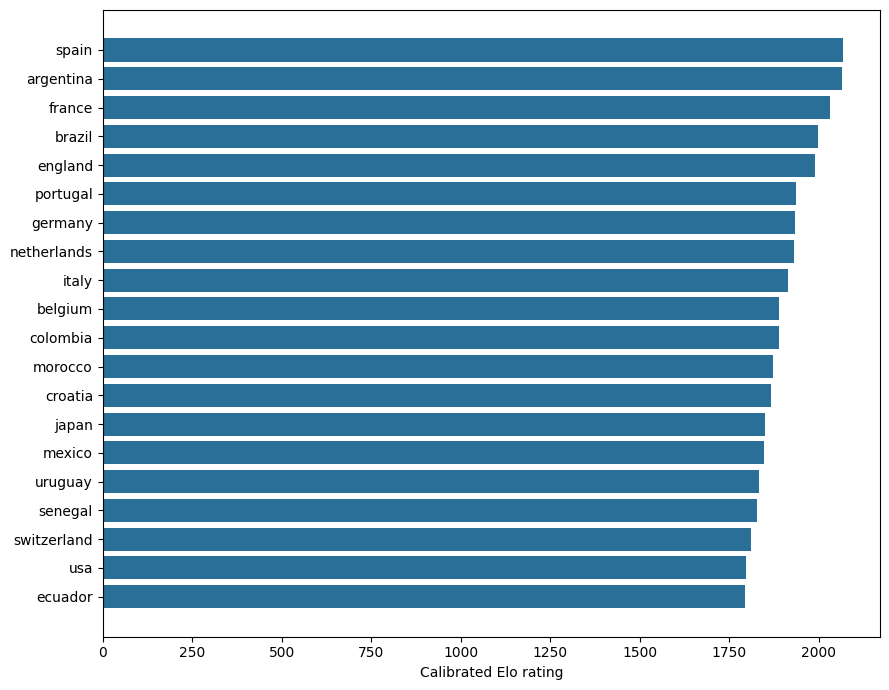

In [5]:
top20 = pd.Series(calibrated_ratings).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20.index[::-1], top20.values[::-1], color="#2a6f97")
ax.set_xlabel("Calibrated Elo rating")
plt.tight_layout()
plt.show()

In [6]:
BURN_IN = 150

def rps_3way(probs, y):
    return 0.5 * ((probs[0] - y[0]) ** 2 + (probs[0] + probs[1] - y[0] - y[1]) ** 2)

def walk_forward_backtest(matches, seed=SEED, home_adv=HOME_ADV, burn_in=BURN_IN, n_bins=10):
    ratings = {}

    def get_r(slug, name):
        key = slug if slug else f"ghost:{name}"
        if key not in ratings:
            ratings[key] = seed.get(slug, 1500) if slug else 1500
        return ratings[key]

    def set_r(slug, name, v):
        ratings[slug if slug else f"ghost:{name}"] = v

    n = hit = fav_n = fav_hit = base_home = base_elo = 0
    brier = logloss = rps = rps_uniform = 0.0
    calib_bins = [{"sumP": 0.0, "sumY": 0.0, "n": 0} for _ in range(n_bins)]

    for i, m in enumerate(matches):
        if m["hg"] is None or m["ag"] is None:
            continue
        ra, rb = get_r(m["homeSlug"], m["homeName"]), get_r(m["awaySlug"], m["awayName"])

        if i >= burn_in:
            p = match_prob(ra, rb, home_adv)
            probs = [p["winA"], p["draw"], p["winB"]]
            actual = 0 if m["hg"] > m["ag"] else 2 if m["hg"] < m["ag"] else 1
            y = [1.0 if actual == k else 0.0 for k in range(3)]
            pred = int(np.argmax(probs))

            if pred == actual:
                hit += 1
            brier += sum((probs[k] - y[k]) ** 2 for k in range(3))
            logloss += -math.log(max(1e-12, probs[actual]))
            rps += rps_3way(probs, y)
            rps_uniform += rps_3way([1/3, 1/3, 1/3], y)
            for k in range(3):
                b = min(n_bins - 1, int(probs[k] * n_bins))
                calib_bins[b]["sumP"] += probs[k]
                calib_bins[b]["sumY"] += y[k]
                calib_bins[b]["n"] += 1
            if max(probs) >= 0.5:
                fav_n += 1
                fav_hit += int(pred == actual)
            base_home += int(actual == 0)
            base_elo += int((0 if expected_score(ra, rb, home_adv) >= 0.5 else 2) == actual)
            n += 1

        exp = expected_score(ra, rb, home_adv)
        score = 1.0 if m["hg"] > m["ag"] else 0.0 if m["hg"] < m["ag"] else 0.5
        delta = base_k(m["leagueName"]) * goal_diff_mult(m["hg"] - m["ag"]) * (score - exp)
        set_r(m["homeSlug"], m["homeName"], ra + delta)
        set_r(m["awaySlug"], m["awayName"], rb - delta)

    ece = sum(abs(b["sumP"]/b["n"] - b["sumY"]/b["n"]) * b["n"] for b in calib_bins if b["n"]) / (3 * n)
    metrics = {
        "evaluated": n, "accuracy": hit / n, "favourite_accuracy": fav_hit / fav_n,
        "brier": brier / n, "logloss": logloss / n, "rps": rps / n, "ece": ece,
        "baseline_always_home": base_home / n, "baseline_pick_higher_elo": base_elo / n,
        "baseline_coin_flip_rps": rps_uniform / n,
    }
    return metrics, calib_bins

metrics, calib_bins = walk_forward_backtest(matches)
pd.Series(metrics).to_frame("value")

,value
evaluated,763.000000
accuracy,0.618611
favourite_accuracy,0.690229
brier,0.520360
logloss,0.885640
rps,0.174610
ece,0.023160
baseline_always_home,0.491481
baseline_pick_higher_elo,0.613368
baseline_coin_flip_rps,0.240644


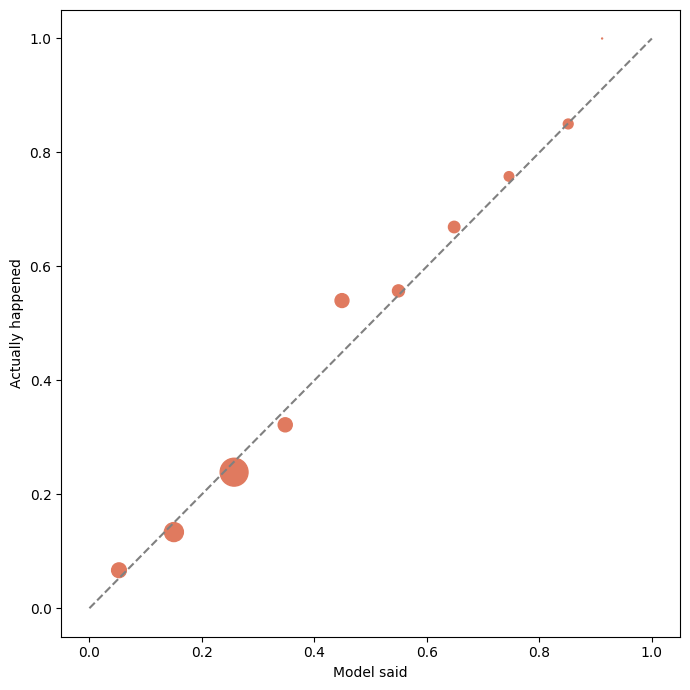

In [7]:
model_said, actually_happened, counts = [], [], []
for b in calib_bins:
    if b["n"] == 0:
        continue
    model_said.append(b["sumP"] / b["n"])
    actually_happened.append(b["sumY"] / b["n"])
    counts.append(b["n"])

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.scatter(model_said, actually_happened, s=[c / 2 for c in counts], color="#e07a5f")
ax.set_xlabel("Model said")
ax.set_ylabel("Actually happened")
plt.tight_layout()
plt.show()

In [8]:
def predict_head_to_head(team_a, team_b, home_team=None, ratings=elo_calibrated["ratings"]):
    ra, rb = ratings[team_a], ratings[team_b]
    hb = HOME_ADV if home_team == team_a else -HOME_ADV if home_team == team_b else 0
    p = match_prob(ra, rb, hb)
    print(team_a, ra, team_b, rb)
    print(team_a, p["winA"], "draw", p["draw"], team_b, p["winB"])
    return p

_ = predict_head_to_head("brazil", "argentina")
_ = predict_head_to_head("usa", "mexico", home_team="usa")

brazil 1955 argentina 1976
brazil 0.3310325504296866 draw 0.28957106428464113 argentina 0.3793963852856722
usa 1826 mexico 1834
usa 0.41368960790602965 draw 0.28186860068277475 mexico 0.3044417914111956


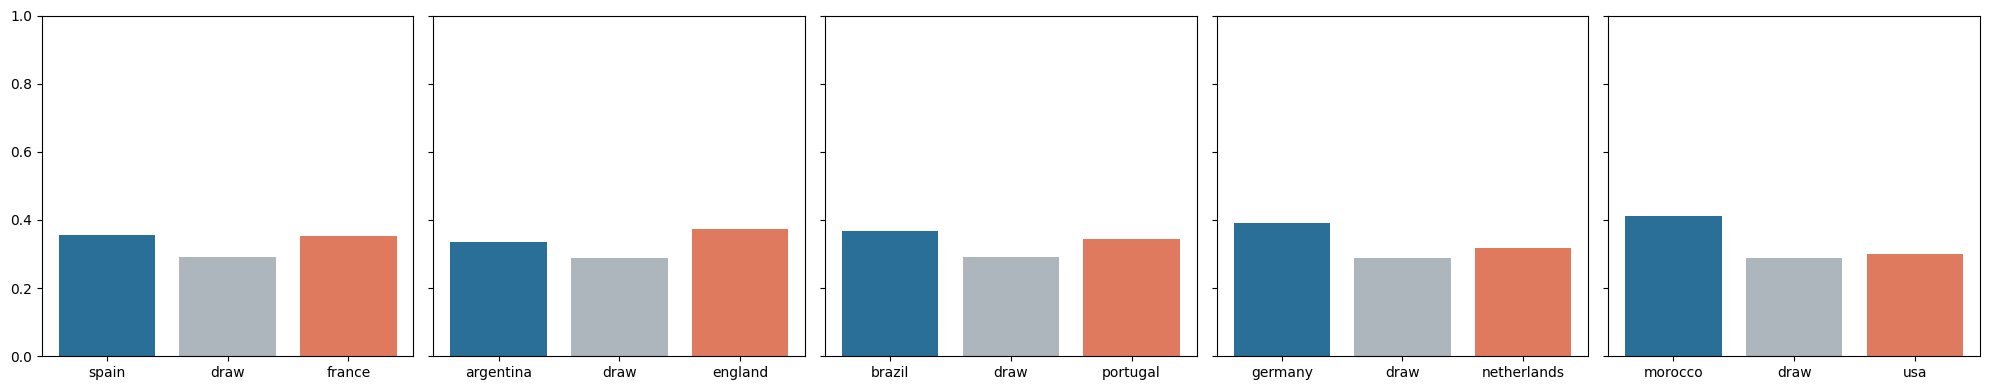

In [9]:
matchups = [
    ("spain", "france"), ("argentina", "england"), ("brazil", "portugal"),
    ("germany", "netherlands"), ("morocco", "usa"),
]
fig, axes = plt.subplots(1, len(matchups), figsize=(4 * len(matchups), 4), sharey=True)
for ax, (a, b) in zip(axes, matchups):
    p = match_prob(elo_calibrated["ratings"][a], elo_calibrated["ratings"][b])
    ax.bar([a, "draw", b], [p["winA"], p["draw"], p["winB"]], color=["#2a6f97", "#adb5bd", "#e07a5f"])
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [10]:
groups = {}
for m in wc2026_data["matches"]:
    g = m.get("group")
    if g:
        groups.setdefault(g, set()).update([m["t1"], m["t2"]])
groups = {g: sorted(teams) for g, teams in groups.items()}

In [11]:
def simulate_group(teams, ratings, rng):
    pts = {t: 0 for t in teams}
    gf = {t: 0 for t in teams}
    ga = {t: 0 for t in teams}
    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            a, b = teams[i], teams[j]
            ga_a, ga_b = sample_scoreline(ratings[a], ratings[b], rng=rng)
            gf[a] += ga_a; ga[a] += ga_b
            gf[b] += ga_b; ga[b] += ga_a
            if ga_a > ga_b:
                pts[a] += 3
            elif ga_a < ga_b:
                pts[b] += 3
            else:
                pts[a] += 1; pts[b] += 1
    return sorted(teams, key=lambda t: (pts[t], gf[t] - ga[t], gf[t]), reverse=True)

def simulate_knockouts(round_teams, ratings, rng):
    round_teams = list(round_teams)
    random.shuffle(round_teams)
    while len(round_teams) > 1:
        nxt = []
        for i in range(0, len(round_teams), 2):
            a, b = round_teams[i], round_teams[i + 1]
            ga_, gb_ = sample_scoreline(ratings[a], ratings[b], allow_draw=False, rng=rng)
            nxt.append(a if ga_ > gb_ else b)
        round_teams = nxt
    return round_teams[0]

def run_tournament_simulation(groups, ratings, n_trials=5000, seed=42):
    rng = random.Random(seed).random
    title_counts = {t: 0 for teams in groups.values() for t in teams}
    for _ in range(n_trials):
        group_ranked = {g: simulate_group(teams, ratings, rng) for g, teams in groups.items()}
        qualifiers = [t for ranked in group_ranked.values() for t in ranked[:2]]
        thirds = [ranked[2] for ranked in group_ranked.values()]
        best_thirds = sorted(thirds, key=lambda t: ratings[t], reverse=True)[:8]
        round_of_32 = qualifiers + best_thirds
        winner = simulate_knockouts(round_of_32, ratings, rng)
        title_counts[winner] += 1
    return pd.Series(title_counts).sort_values(ascending=False) / n_trials

N_TRIALS = 5000
title_odds = run_tournament_simulation(groups, elo_calibrated["ratings"], n_trials=N_TRIALS)
title_odds.head(15).to_frame("title probability")

,title probability
spain,0.1550
france,0.1534
england,0.1298
argentina,0.0990
brazil,0.0780
portugal,0.0722
germany,0.0562
netherlands,0.0296
belgium,0.0288
colombia,0.0264


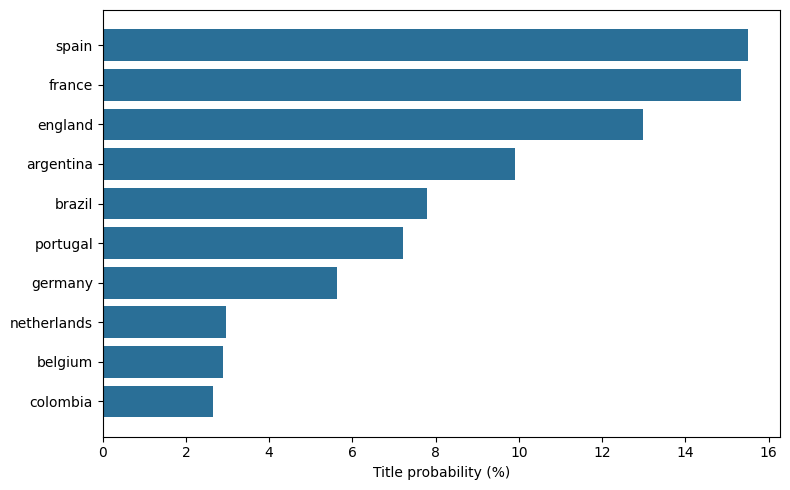

In [12]:
top10 = title_odds.head(10)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10.index[::-1], top10.values[::-1] * 100, color="#2a6f97")
ax.set_xlabel("Title probability (%)")
plt.tight_layout()
plt.show()

In [13]:
wc_rows = []
for m in wc2026_data["matches"]:
    if m.get("g1") is None or m.get("g2") is None:
        continue
    ra, rb = elo_calibrated["ratings"].get(m["t1"]), elo_calibrated["ratings"].get(m["t2"])
    if ra is None or rb is None:
        continue
    p = match_prob(ra, rb)
    actual = 0 if m["g1"] > m["g2"] else 2 if m["g1"] < m["g2"] else 1
    pred = int(np.argmax([p["winA"], p["draw"], p["winB"]]))
    wc_rows.append({
        "date": m["date"], "match": f"{m['team1']} {m['g1']}-{m['g2']} {m['team2']}",
        "model_pick": m["team1"] if pred == 0 else m["team2"] if pred == 2 else "draw",
        "correct": pred == actual,
    })

wc_df = pd.DataFrame(wc_rows).sort_values("date")
print(wc_df["correct"].sum(), "/", len(wc_df))
wc_df.tail(15)

63 / 92


,date,match,model_pick,correct
78,2026-06-30,France 3-0 Sweden,France,True
81,2026-07-01,Mexico 2-0 Ecuador,Mexico,True
82,2026-07-01,England 2-1 DR Congo,England,True
83,2026-07-01,Belgium 3-2 Senegal,Belgium,True
75,2026-07-02,USA 2-0 Bosnia & Herzegovina,USA,True
86,2026-07-02,Spain 3-0 Austria,Spain,True
84,2026-07-02,Portugal 2-1 Croatia,Portugal,True
87,2026-07-03,Switzerland 2-0 Algeria,Switzerland,True
80,2026-07-03,Argentina 3-2 Cape Verde,Argentina,True
79,2026-07-03,Australia 1-1 Egypt,Australia,False
